# Modelo de riego que evalúa la permanencia del empleado

En el siguiente notebook se identifica variables significativas que influyen 



## Importación de las librerías

In [5]:
# Funciones básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Flujo que incluye técnicas de balanceo de clases
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
# Preprocesamiento de datos
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
# División del conjunto de datos en entrenamiento y prueba
from sklearn.model_selection import train_test_split
# 
from sklearn.feature_selection import VarianceThreshold

In [6]:
pip -q install lifelines

Note: you may need to restart the kernel to use updated packages.


In [7]:
pip -q install scikit-survival

Note: you may need to restart the kernel to use updated packages.


In [8]:
# Análisis de supervivencia.
from lifelines import KaplanMeierFitter
# Ajusta el modelo de riesgos proporcionales de Cox
from lifelines import CoxPHFitter
# Medida de desempeño muy usada en análisis de supervivencia
from lifelines.utils import concordance_index
# Estima la función de supervivencia mediante el método de Kaplan–Meier.
from lifelines import KaplanMeierFitter
# Crea el objeto de supervivencia
from sksurv.util import Surv
# Mide qué tan buenas son las predicciones probabilísticas
from sksurv.metrics import brier_score

## Importación del dataset

In [9]:
df = pd.read_csv("/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Descripción de los datos

In [10]:
print(df.describe())

               Age    DailyRate  DistanceFromHome    Education  EmployeeCount  \
count  1470.000000  1470.000000       1470.000000  1470.000000         1470.0   
mean     36.923810   802.485714          9.192517     2.912925            1.0   
std       9.135373   403.509100          8.106864     1.024165            0.0   
min      18.000000   102.000000          1.000000     1.000000            1.0   
25%      30.000000   465.000000          2.000000     2.000000            1.0   
50%      36.000000   802.000000          7.000000     3.000000            1.0   
75%      43.000000  1157.000000         14.000000     4.000000            1.0   
max      60.000000  1499.000000         29.000000     5.000000            1.0   

       EmployeeNumber  EnvironmentSatisfaction   HourlyRate  JobInvolvement  \
count     1470.000000              1470.000000  1470.000000     1470.000000   
mean      1024.865306                 2.721769    65.891156        2.729932   
std        602.024335            

In [11]:
print(df.describe(include="object"))

       Attrition BusinessTravel              Department EducationField Gender  \
count       1470           1470                    1470           1470   1470   
unique         2              3                       3              6      2   
top           No  Travel_Rarely  Research & Development  Life Sciences   Male   
freq        1233           1043                     961            606    882   

                JobRole MaritalStatus Over18 OverTime  
count              1470          1470   1470     1470  
unique                9             3      1        2  
top     Sales Executive       Married      Y       No  
freq                326           673   1470     1054  


In [12]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

## Evaluación estadística del impacto de cada variable sobre la permanencia laboral mediante el modelo de Cox
### Definición del indicador de evento (Attrition)

In [13]:
df = df.copy()
df.loc[:,"salida"] = df["Attrition"].apply(lambda x: 1 if x == "Yes" else 0)

### Pipeline de transformación y selección de variables

In [14]:
num_cols = df.select_dtypes(include=np.number).columns.drop(["salida","YearsAtCompany","EmployeeNumber"]).tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.drop("Attrition").tolist()

preprocessor = ColumnTransformer([
    ("scaler", StandardScaler(), num_cols),
    ("ohe", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False), cat_cols)
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("var_thresh", VarianceThreshold(threshold=0.1))
])

### Preprocesamiento de los datos

In [15]:
df_pre = pipeline.fit_transform(df)

features_pre = pipeline.named_steps["preprocessor"].get_feature_names_out()
mask = pipeline.named_steps["var_thresh"].get_support()

features = features_pre[mask]
features = [col.replace("scaler__","")
                 .replace("ohe__","")
                 .replace("remainder__","") for col in features]

df_pre = pd.DataFrame(df_pre, columns=features)

In [16]:
y_event = df["salida"]
y_time = df["YearsAtCompany"]

df_pre = df_pre.copy()
df_pre["YearsAtCompany"] = y_time.values
df_pre["salida"] = y_event.values

cph = CoxPHFitter()
cph.fit(df_pre, duration_col="YearsAtCompany", event_col="salida")
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1470 total observations, 1233 right-censored observations>
             duration col = 'YearsAtCompany'
                event col = 'salida'
      baseline estimation = breslow
   number of observations = 1470
number of events observed = 237
   partial log-likelihood = -1159.41
         time fit was run = 2026-05-19 00:32:45 UTC

---
                                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                          
Age                               -0.15      0.86      0.10           -0.34            0.04                0.71                1.04
DailyRate                         -0.05      0.95      0.07           -0.18            0.08                0.83                1.09
DistanceFromHome                   0.21      1.23      0.07            0.08            0.34                1.08                1.40
Education                         -0.01      0.99      0.07           -0.14            0.13                0.87                1.13
EnvironmentSatisfaction           -0.34      0.71      0.07           -0.47           -0.21                0.62                0.81
HourlyRate                         0.04      1.04      0.07           -0.10            0.17                0.91                1.19
JobInvolvement                    -0.19      0.83      0.06           -0.31           -0.06                0.73                0.94
JobLevel                          -0.14      0.87      0.30           -0.71            0.44                0.49                1.56
JobSatisfaction                   -0.40      0.67      0.07           -0.54           -0.27                0.58                0.76
MonthlyIncome                     -0.24      0.79      0.28           -0.79            0.31                0.45                1.37
MonthlyRate                        0.10      1.11      0.07           -0.03            0.24                0.97                1.27
NumCompaniesWorked                 0.64      1.90      0.07            0.50            0.78                1.65                2.19
PercentSalaryHike                  0.03      1.03      0.11           -0.18            0.25                0.83                1.28
PerformanceRating                 -0.02      0.98      0.11           -0.24            0.20                0.79                1.22
RelationshipSatisfaction          -0.22      0.80      0.07           -0.36           -0.08                0.70                0.92
StockOptionLevel                  -0.17      0.84      0.11           -0.38            0.04                0.68                1.04
TotalWorkingYears                 -1.20      0.30      0.24           -1.66           -0.74                0.19                0.48
TrainingTimesLastYear             -0.27      0.77      0.08           -0.42           -0.11                0.66                0.89
WorkLifeBalance                   -0.11      0.89      0.06           -0.24            0.01                0.79                1.01
YearsInCurrentRole                -1.21      0.30      0.13           -1.46           -0.97                0.23                0.38
YearsSinceLastPromotion            0.20      1.22      0.10           -0.01            0.40                0.99                1.49
YearsWithCurrManager              -1.20      0.30      0.12           -1.44           -0.95                0.24                0.39
BusinessTravel_Travel_Frequently   1.38      3.97      0.34            0.72            2.04                2.05                7.68
BusinessTravel_Travel_Rarely       0.85      2.33      0.32            0.22            1.47                1.25                4.35
Department_Research & Development -0.50      0.61      0.39           -1.26            0.26                0.28                1.30
Department_Sales                   0.83      2.30      0.37     

#### Interpretación:
- Variables significativas y que **AUMENTA** el riesgo de rotación:
    - ```OverTime_Yes```
    - ```BusinessTravel_Travel_Frequently```
    - ```JobRole_Laboratory Technician```
    - ```Department_Sales```
    - ```BusinessTravel_Travel_Rarely```
    - ```MaritalStatus_Single```
    - ```NumCompaniesWorked```
    - ```Gender_Male```
    - ```DistanceFromHome```
      
- Variables significativas y que **REDUCEN** el riesgo de rotación:
    - ```YearsInCurrentRole```
    - ```YearsWithCurrManager```
    - ```TotalWorkingYears```
    - ```JobSatisfaction```
    - ```EnvironmentSatisfaction```
    - ```TrainingTimesLastYear```
    - ```RelationshipSatisfaction```
    - ```JobInvolvement```
    - ```EducationField_Medical```
    - ```EducationField_Life Sciences```
    - ```JobRole_Sales Executive```
  

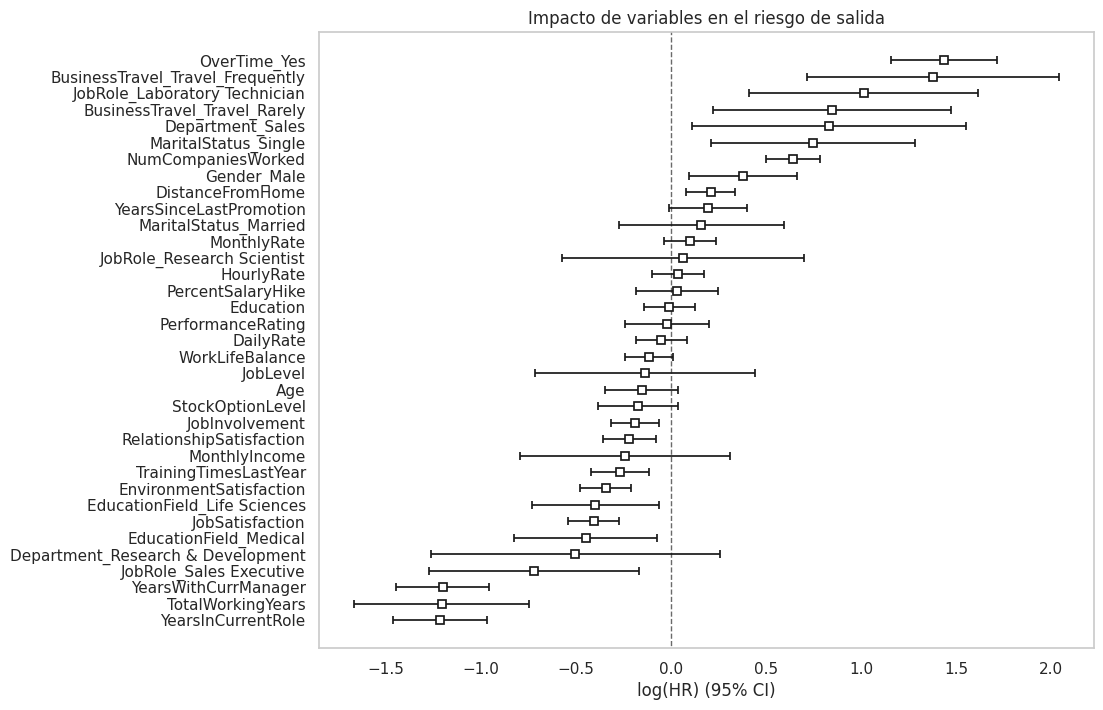

In [17]:
plt.figure(figsize=(10, 8))
cph.plot()
plt.title("Impacto de variables en el riesgo de salida")
plt.grid()
plt.show()

## Modelo de riesgos proporcionales de Cox
### Separación de la muestra de entrenamiento y prueba

In [18]:
df_train, df_test = train_test_split(df, test_size=0.2, stratify=df["salida"], random_state=42)

### Preprocesamiento de datos de las muestras de entrenamiento y prueba

In [19]:
X_train = df_train.drop(columns=["salida", "YearsAtCompany"])
X_test = df_test.drop(columns=["salida", "YearsAtCompany"])

y_train = df_train[["salida", "YearsAtCompany"]]
y_test = df_test[["salida", "YearsAtCompany"]]

X_pre_train = pipeline.fit_transform(X_train)
X_pre_test = pipeline.transform(X_test)

features_pre = pipeline.named_steps["preprocessor"].get_feature_names_out()
mask = pipeline.named_steps["var_thresh"].get_support()

features = features_pre[mask]
features = [col.replace("scaler__","")
                 .replace("ohe__","")
                 .replace("remainder__","") for col in features]

X_pre_train = pd.DataFrame(X_pre_train, columns=features)
X_pre_test = pd.DataFrame(X_pre_test, columns=features)

df_pre_train = pd.concat([X_pre_train.reset_index(drop=True),
                          y_train.reset_index(drop=True)], axis=1)

df_pre_test = pd.concat([X_pre_test.reset_index(drop=True),
                         y_test.reset_index(drop=True)], axis=1)

### Métricas de evaluación del desempeño del modelo de riesgo

- **C-index (Índice de concordancia):**
Métrica de discriminación del riesgo, que mide qué tan bien el modelo ordena a los individuos según su riesgo, asignando mayor riesgo a quienes experimentan el evento antes.

$$
\text {Probabilidad de que el modelo asigne mayor riesgo a quien ocurre antes el evento.}
$$
$$
C=P(\hat r_i > \hat r_j | t_i < t_j)
$$
$$
\text{Baremo del C-index, medida de discriminación de un modelo de supervivencia}
$$
$$
\begin{aligned}
0.5 &\rightarrow \text{No discriminación (equivalante al azar)} \\
0.5 - 0.6 &\rightarrow \text{Muy pobre} \\
0.6 - 0.7 &\rightarrow \text{Pobre / Aceptable bajo} \\
0.7 - 0.8 &\rightarrow \text{Bueno} \\
0.8 - 0.9 &\rightarrow \text{Muy bueno} \\
{> 0.90} &\rightarrow \text{Excelente (raro en datos reales)} \\
{1.00} &\rightarrow \text{Perfecto (sospechoso / sobreajuste)} \\
\end{aligned}
$$


- **Brier Score:** Métrica de calibración y precisión probabilística, que evalúa qué tan cercanas son las probabilidades predichas por el modelo a los resultados observados.

    - $Y_i \in \{0,1\}: \text{resultado observado}$
    - $\hat p_i: \text{probabilidad predicha de } Y_i=1$

$$
BS=\frac{1}{n}\sum_{i=1}^{n}(\hat p_i-Y_i)^2
$$

$$
\text{Baremo del Brier Score, mide la calidad de las predicciones probabilísticas, evaluando que tan cerca están las probabilidades predichas de los resultados reales.}
$$
$$
\begin{aligned}
0.00 - 0.05 &\rightarrow \text{Excelente} \\
0.05 - 0.10 &\rightarrow \text{Muy bueno} \\
0.10 - 0.20 &\rightarrow \text{Aceptable} \\
0.20 - 0.30 &\rightarrow \text{Pobre} \\
{> 0.30} &\rightarrow \text{Muy malo} \\
\end{aligned}
$$

### Análisis del C-index

In [20]:
cph = CoxPHFitter(penalizer=0.3)
cph.fit(df_pre_train, duration_col="YearsAtCompany", event_col="salida")

cindex_train = cph.score(df_pre_train, scoring_method="concordance_index")
print(f"C-index (train): {cindex_train:.3f}")

# Predicción de riesgo (hazard parcial)
risk_scores_test = cph.predict_partial_hazard(df_pre_test)
cindex_test = concordance_index(y_test["YearsAtCompany"],
                                -risk_scores_test,   # signo negativo: mayor riesgo → menor tiempo
                                y_test["salida"])
print(f"C-index (test): {cindex_test:.3f}")

C-index (train): 0.934
C-index (test): 0.920


#### Interpretación:
- El modelo presentó un índice de concordancia (**C-index**) de **0.934** en el conjunto de entrenamiento y de **0.920** en el conjunto de prueba, lo que indica una capacidad de discriminación muy buena.


### Creación de niveles de riesgo

In [21]:
df_pre_test = df_pre_test.copy()
df_pre_test["riesgo_renuncia"] = risk_scores_test
df_pre_test["nivel_riesgo_renuncia"] = pd.qcut(df_pre_test["riesgo_renuncia"],
                                           q=3, labels=["Bajo", "Medio", "Alto"])

### Análisis de Brier Score

In [22]:
# Objetos de supervivencia
y_train = Surv.from_dataframe(event="salida",
                              time="YearsAtCompany",
                              data=df_pre_train[["salida", "YearsAtCompany"]])
y_test = Surv.from_dataframe(event="salida",
                             time="YearsAtCompany",
                             data=df_pre_test[["salida", "YearsAtCompany"]])
# horizonte temporal
times = np.array([10, 20, 30])
# predicciones de supervivencia
surv_preds = cph.predict_survival_function(df_pre_test, times=times)
S_pred = surv_preds.T.values  # (n_samples, n_times)
# Brier score IPCW
times_out, brier_scores = brier_score(survival_train=y_train,
                                      survival_test=y_test,
                                      estimate=S_pred,
                                      times=times)
print(f"Brier score IPCW a {times_out[0]} años: {brier_scores[0]:.4f}")
print(f"Brier score IPCW a {times_out[1]} años: {brier_scores[1]:.4f}")
print(f"Brier score IPCW a {times_out[2]} años: {brier_scores[2]:.4f}")

Brier score IPCW a 10 años: 0.0910
Brier score IPCW a 20 años: 0.0799
Brier score IPCW a 30 años: 0.1271


#### Interpretación:
- La evaluación de Brier Score ajustado por censura (**IPCW**) a los 10 años arrojó un valor de **0.0910**, este resultado sugiere un nivel **excelente**.
- La evaluación de Brier Score ajustado por censura (**IPCW**) a los 20 años arrojó un valor de **0.0799**, este resultado sugiere un nivel **excelente**.
- La evaluación de Brier Score ajustado por censura (**IPCW**) a los 30 años arrojó un valor de **0.1271**, este resultado sugiere un nivel **aceptable**.

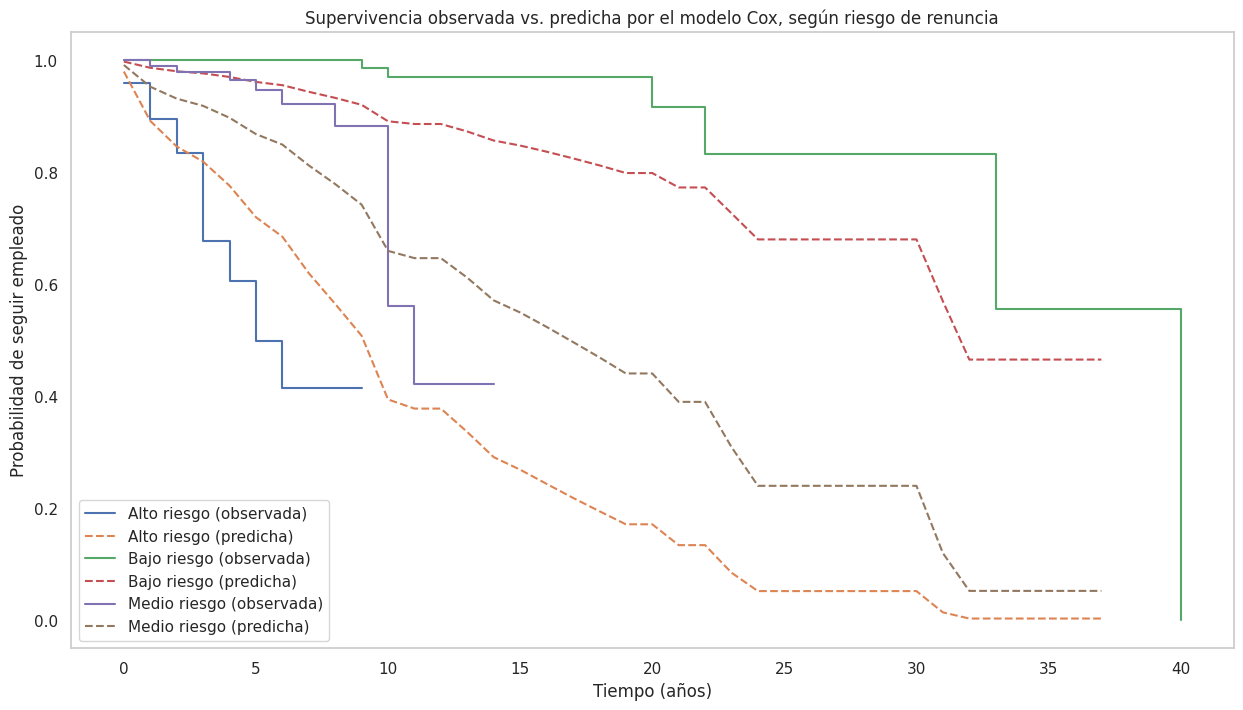

In [23]:
kmf = KaplanMeierFitter()
plt.figure(figsize=(15, 8))

for nivel in df_pre_test["nivel_riesgo_renuncia"].unique():
    subset = df_pre_test[df_pre_test["nivel_riesgo_renuncia"] == nivel]
    # Curva OBSERVADA (KM)
    kmf.fit(subset["YearsAtCompany"],
            subset["salida"], label=f"{nivel} riesgo (observada)")
    kmf.plot(ci_show=False)
    # Curva PREDICHA (Cox)
    surv_pred = cph.predict_survival_function(subset)
    # Promedio de supervivencia del grupo
    mean_surv = surv_pred.mean(axis=1)
    plt.plot(mean_surv.index,
             mean_surv.values,
             linestyle="--",
             label=f"{nivel} riesgo (predicha)")
plt.title("Supervivencia observada vs. predicha por el modelo Cox, según riesgo de renuncia")
plt.xlabel("Tiempo (años)")
plt.ylabel("Probabilidad de seguir empleado")
plt.legend()
plt.grid()
plt.savefig("prueba.jpg")
plt.show()

### Interpretación:
- El modelo de Cox muestra una adecuada capacidad de discriminación, evidenciada por la segmentación de los individuos en niveles de riesgo. Pero cabe resaltar que el modelo tiende a subestimar la supervivencia en todos los grupos de riesgo (alto, medio y bajo), lo que implica una sobreestimación riesgo.